In [1]:
# DRIFTED DATA 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import zscore

data = np.loadtxt("FAK.txt", skiprows=1)
t = data[:, 0]
x = data[:, 1]
dt = 8.494e-4#[s] 

# len(T) = 47_778_391


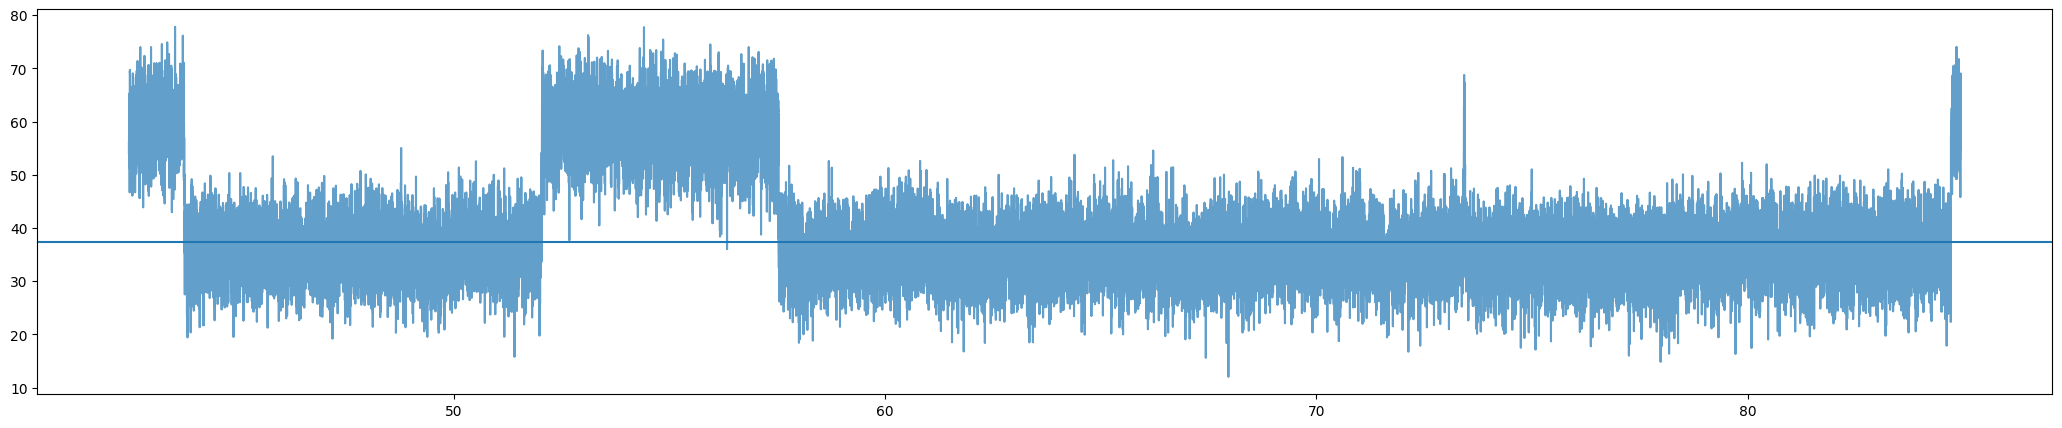

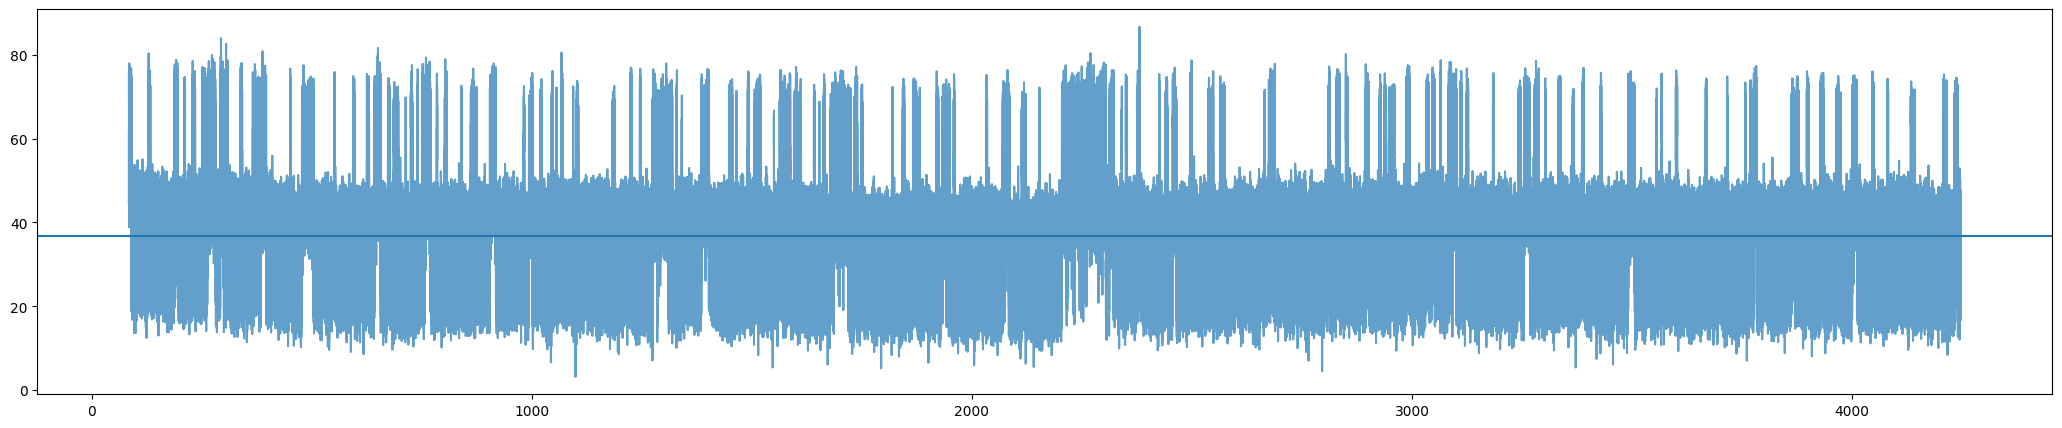

In [2]:
q = 100_000
p = 5_000_000
#plot 
plt.figure(figsize=(26, 5))
plt.plot(t[50_000:q], x[50_000:q], alpha = 0.7); plt.axhline(np.mean(x[0:q])); plt.show()
plt.figure(figsize=(26, 5))
plt.plot(t[q:p], x[q:p], alpha = 0.7); plt.axhline(np.mean(x[q:p])); plt.show()


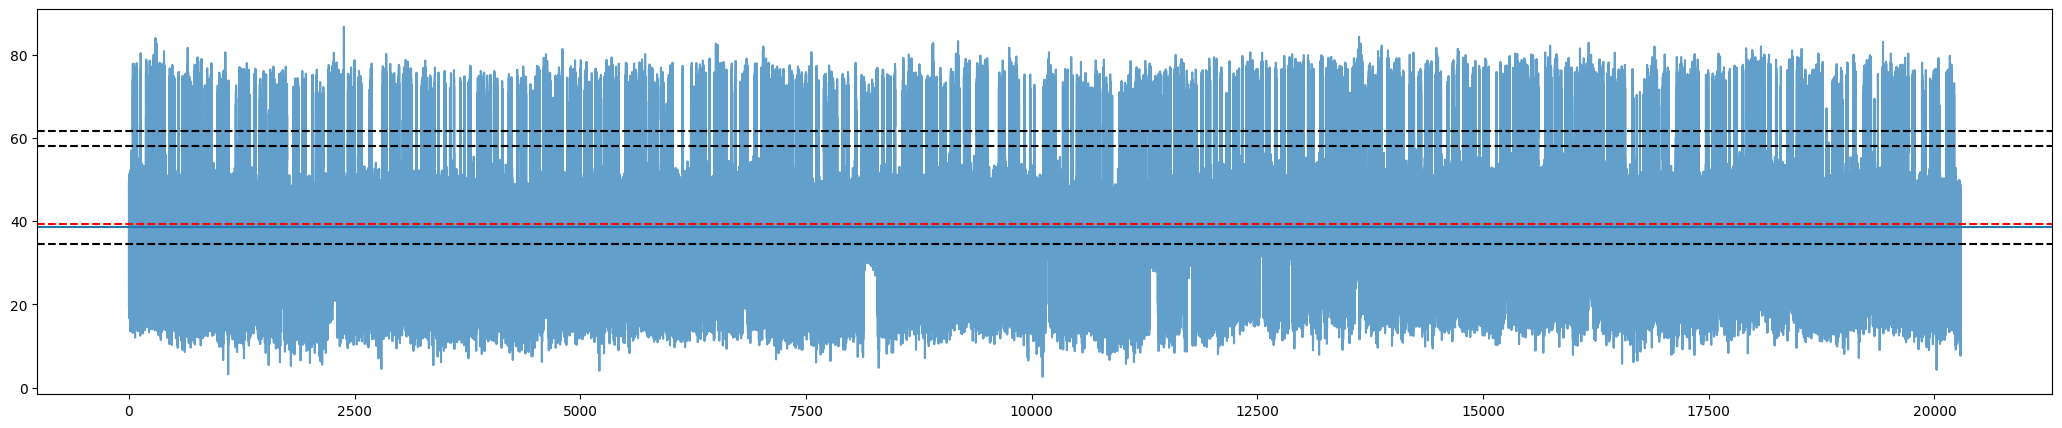

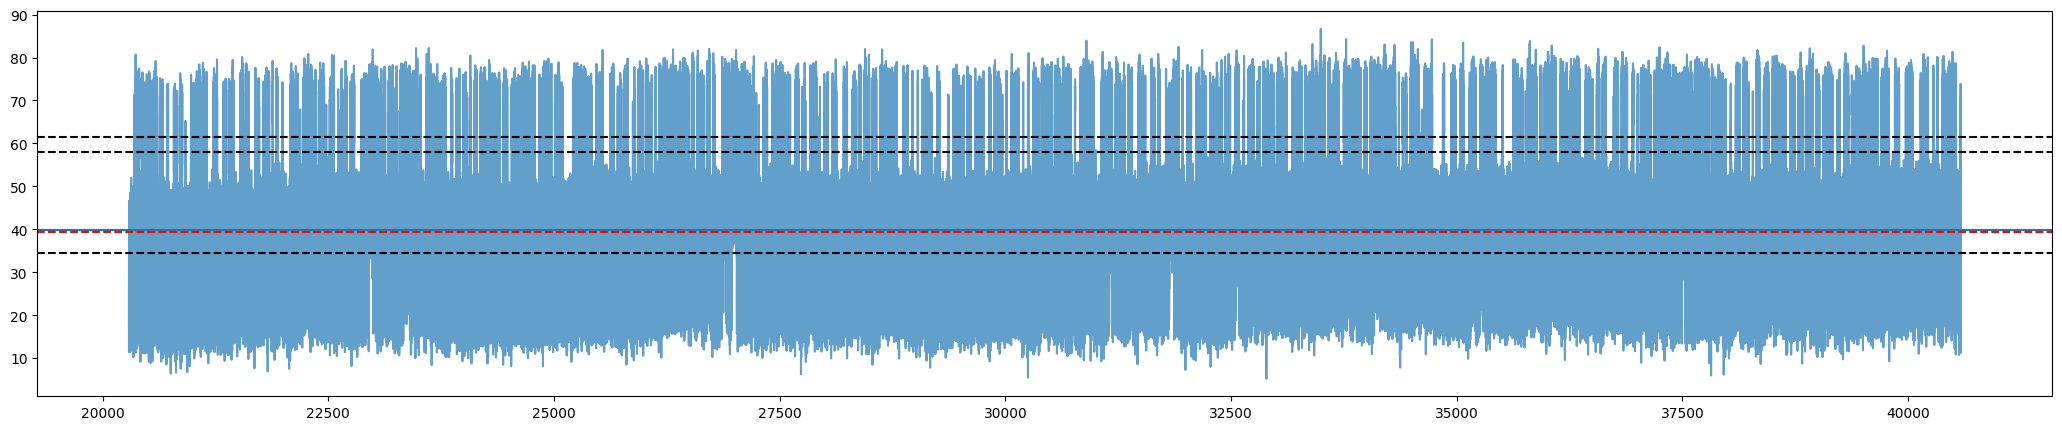

In [3]:

plt.figure(figsize=(26, 5))
plt.plot(t[:int(len(t)/2)], x[:int(len(x)/2)], alpha = 0.7); plt.axhline(np.mean(x[:int(len(x)/2)])); plt.axhline(np.mean(x), linestyle = "--", c="red")
for i in [34.42, 57.96, 61.60]:
    plt.axhline(i, linestyle = "--", c = "black")
plt.show()

plt.figure(figsize=(26, 5))
plt.plot(t[int(len(t)/2):], x[int(len(x)/2):], alpha = 0.7); plt.axhline(np.mean(x[int(len(x)/2):])); plt.axhline(np.mean(x), linestyle = "--", c="red")
for i in [34.42, 57.96, 61.60]:
    plt.axhline(i, linestyle = "--", c = "black")
plt.show()

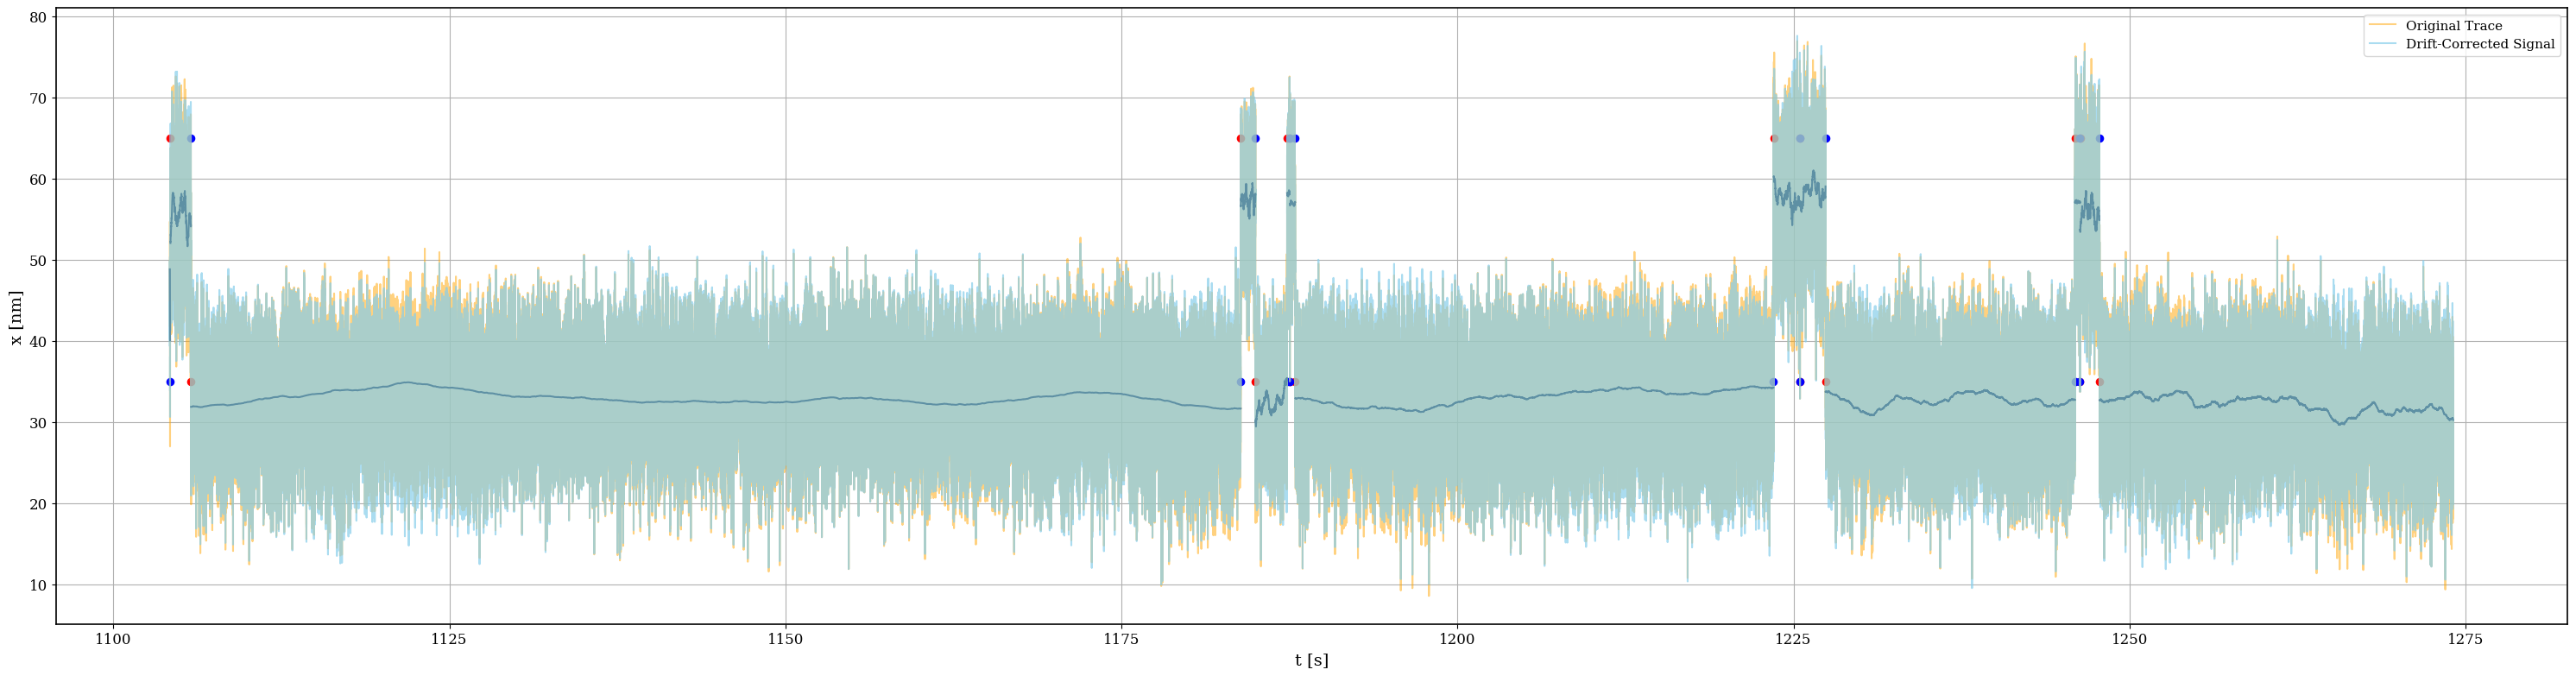

Numero di transizioni rilevate: 16
Salto #01:  from idx 17  →  to idx 50, len: 33
Salto #02:  from idx 1837  →  to idx 1854, len: 17
Salto #03:  from idx 93789  →  to idx 93805, len: 16
Salto #04:  from idx 95079  →  to idx 95086, len: 7
Salto #05:  from idx 97850  →  to idx 97862, len: 12
Salto #06:  from idx 98082  →  to idx 98101, len: 19
Salto #07:  from idx 98101  →  to idx 98110, len: 9
Salto #08:  from idx 98556  →  to idx 98580, len: 24
Salto #09:  from idx 140464  →  to idx 140489, len: 25
Salto #10:  from idx 142773  →  to idx 142782, len: 9
Salto #11:  from idx 142782  →  to idx 142795, len: 13
Salto #12:  from idx 145020  →  to idx 145032, len: 12
Salto #13:  from idx 166867  →  to idx 166877, len: 10
Salto #14:  from idx 167310  →  to idx 167314, len: 4
Salto #15:  from idx 167314  →  to idx 167322, len: 8
Salto #16:  from idx 169005  →  to idx 169028, len: 23


In [15]:
mask = np.full_like(x, np.nan)
mask[x < 35] = 35
mask[x > 60] = 65

start = 1_300_000
fine  = 1_500_000 # intervallo da visualizzare
t_win = t[start:fine]
x_win = x[start:fine]
mask_win  = mask[start:fine]

valid_idx   = np.where(~np.isnan(mask_win))[0]      # array di indici
valid_vals  = mask_win[valid_idx]                   # i loro valori (30/68)

change_pos  = np.where(valid_vals[1:] != valid_vals[:-1])[0] + 1

idx_from = valid_idx[change_pos - 1]    # ultimo indice del blocco corrente
idx_to   = valid_idx[change_pos]        # primo indice del blocco successivo


plt.figure(figsize=(30, 8))
plt.scatter(t_win[idx_to], mask_win[idx_to], c='red', s=35)
plt.scatter(t_win[idx_from], mask_win[idx_from], c='blue', s=35)
plt.plot(t_win, x[start:fine], color='orange', alpha=0.5, label="Original Trace")
x_detrend = np.full_like(x_win, np.nan)
start = 0

for i_from, i_to in zip(idx_from, idx_to):
    # plateau
    end = i_from
    seg = x_win[start:end+1]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 1)
    else:
        win = max(1, len(seg) // 10)

    drift = pd.Series(seg).rolling(win, center=True, min_periods=1).mean().values
    t_drift = t_win[start:start+len(drift)]
    plt.plot(t_drift, drift, color="black", alpha=1)
    delta = np.mean(seg) -  drift
    x_detrend[start:end+1] = seg + delta


## transition
    seg_trans = x_win[end+1:i_to]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 1)
    else:
        win = max(1, len(seg) // 10)
    win_trans = win
    drift_trans = pd.Series(seg_trans).rolling(win_trans, center=True, min_periods=1).mean().values
    delta_trans = np.mean(seg_trans) - drift_trans
    x_detrend[end+1:i_to] = seg_trans + delta_trans

    start = i_to

# ultimo blocco
if start < fine:
    seg = x_win[start:fine]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 3)
    else:
        win = max(1, len(seg) // 20)

    drift = pd.Series(seg).rolling(win, center=True, min_periods=1).mean().values
    t_drift = t_win[start:start+len(drift)]
    plt.plot(t_drift, drift, color='black', alpha=1)
    delta =  np.mean(seg) -  drift
    x_detrend[start:fine] = seg + delta



#plot traiettoria detrended finale
plt.plot(t_win, x_detrend, label="Drift-Corrected Signal", c="skyblue",alpha=0.7)
plt.xlabel('t [s]')
plt.ylabel('x [nm]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("FAK_detrended.pdf")
plt.show()


offset = 0

# PLOT TRANSIZIONI 
# for i_from, i_to in zip(idx_from, idx_to):
#     i_start = max(i_from - offset, 0)
#     i_end   = min(i_to   + offset, fine-1)
#     plt.plot(t_win[i_start:i_end+1], x_win[i_start:i_end+1], color='purple', lw=1, alpha=.8)
# plt.xlabel('t [s]'); plt.ylabel('x [nm]'); plt.title('Segmenti ±10 campioni intorno ai salti 30 ↔ 68')
# plt.show()

print(f'Numero di transizioni rilevate: {len(idx_from)}')
# # idx_from  = ultimo indice del plateau corrente   (30 o 68)
# # idx_to    = primo indice del plateau successivo (68 o 30)

# # PRINT TRANSITIONS
for k, (i_from, i_to) in enumerate(zip(idx_from, idx_to), start=1):
    print(f"Salto #{k:02d}:  from idx {i_from }  →  to idx {i_to}, len: {i_to - i_from}")

# # Costruzione dati
# data = []
# for i, (i_from, i_to) in enumerate(zip(idx_from, idx_to)):
#     dt = t_win[i_to] - t_win[i_from]
#     transition_type = 'unfolding' if i % 2 == 0 else 'folding'
#     data.append((i_from, i_to, dt, transition_type, t_win[i_from], t_win[i_to]))

# df = pd.DataFrame(data, columns=["start_idx", "end_idx", "duration", "type", "t_1", "t_2"])
# df.to_pickle("FAK_transitions.pkl")

# np.save("x_detrend.npy", x_detrend)

X values of histogram peaks (cleaned): [ 9.42128603 10.34409611 11.4976087  11.95901373 12.42041877 12.88182381
 13.57393136 14.26603891 14.95814647 18.18798172 18.64938676 19.57219683
 20.72570942 22.34062705 26.03186734 29.49240511 30.6459177  31.10732274
 31.79943029 32.49153785 32.95294288 33.41434792 34.79856303 35.25996806
 38.2591008  43.79596124 44.71877131 45.64158138 46.33368893 47.25649901
 47.71790404 48.17930908 49.33282167 49.79422671 50.25563174 50.9477393
 51.40914433 52.10125189 52.79335944 53.25476448 53.71616951 54.63897959
 55.10038462 55.79249218 56.94600477 57.86881484 58.5609224  59.9451375
 61.0986501  62.25216269 63.17497276 64.55918787 65.0205929  65.48199794
 67.09691557 69.86534578 70.55745334 71.24956089 72.17237097 72.86447852
 74.01799111 74.94080118 75.63290874 76.32501629]


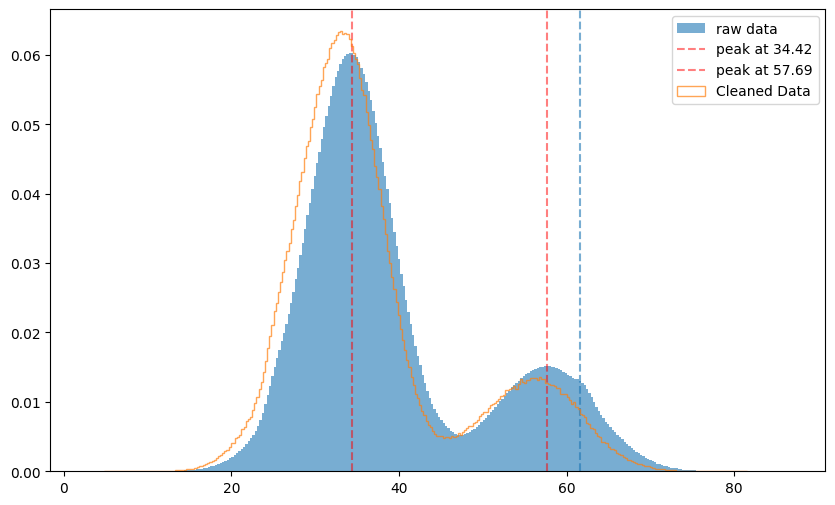

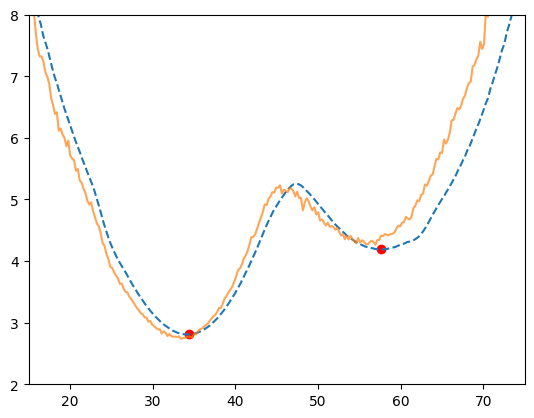

In [104]:
plt.figure(figsize=(10, 6))

counts, bin_edges = np.histogram(x, bins=300, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peaks_indices, _ = find_peaks(counts, height = 0.01)
peak_x_values = bin_centers[peaks_indices]
plt.hist(x, bins = 300, density=True, alpha=0.6, label="raw data"); plt.legend()
for i in peak_x_values:
    plt.axvline(i, color='red', linestyle='--', alpha=0.5, label = f"peak at {i:.2f}"); plt.legend()
plt.axvline(x = 61.6, linestyle='--', alpha=0.6)

counts2, bin_edges2 = np.histogram(x_detrend, bins=300, density=True)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
peaks_indices2, _ = find_peaks(counts2)
peak_x_values2 = bin_centers2[peaks_indices2]
print("X values of histogram peaks (cleaned):", peak_x_values2)

x_detrend = np.load("x_detrend.npy")
plt.hist(x_detrend, bins=300, density = True, histtype="step" , alpha=0.7, label = "Cleaned Data") 
plt.legend(); plt.show()



# boltzmann U(x)
U = -np.log(counts + 1e-10)
U2 = -np.log(counts2 + 1e-10)
plt.plot(bin_centers, U, linestyle = "--"); plt.plot(bin_centers2, U2, alpha = 0.7); plt.ylim(2, 8); plt.xlim(15,75)
plt.scatter(peak_x_values[0], U[peaks_indices[0]], color='red', label='Peak 1')
plt.scatter(peak_x_values[1], U[peaks_indices[1]], color='red', label='Peak 1')
#maxima peak
